Klasse mapping:
BrownNoise -> 0
GreenNoise -> 1
NoNoise -> 2
PinkNoise -> 3
WhiteNoise -> 4

Validation Accuracy: 0.991304347826087

Classification Report (Validation):
              precision    recall  f1-score   support

  BrownNoise       1.00      1.00      1.00        69
  GreenNoise       1.00      1.00      1.00        69
     NoNoise       1.00      1.00      1.00        69
   PinkNoise       0.96      1.00      0.98        69
  WhiteNoise       1.00      0.96      0.98        69

    accuracy                           0.99       345
   macro avg       0.99      0.99      0.99       345
weighted avg       0.99      0.99      0.99       345


Confusion Matrix (Validation):
[[69  0  0  0  0]
 [ 0 69  0  0  0]
 [ 0  0 69  0  0]
 [ 0  0  0 69  0]
 [ 0  0  0  3 66]]

Unikke targets i test: [0 1 2 3 4]
Antal prøver pr. klasse: [100 100 100 100 100]

Test Accuracy: 0.944

Classification Report (Test):
              precision    recall  f1-score   support

  BrownNoise       0.99     

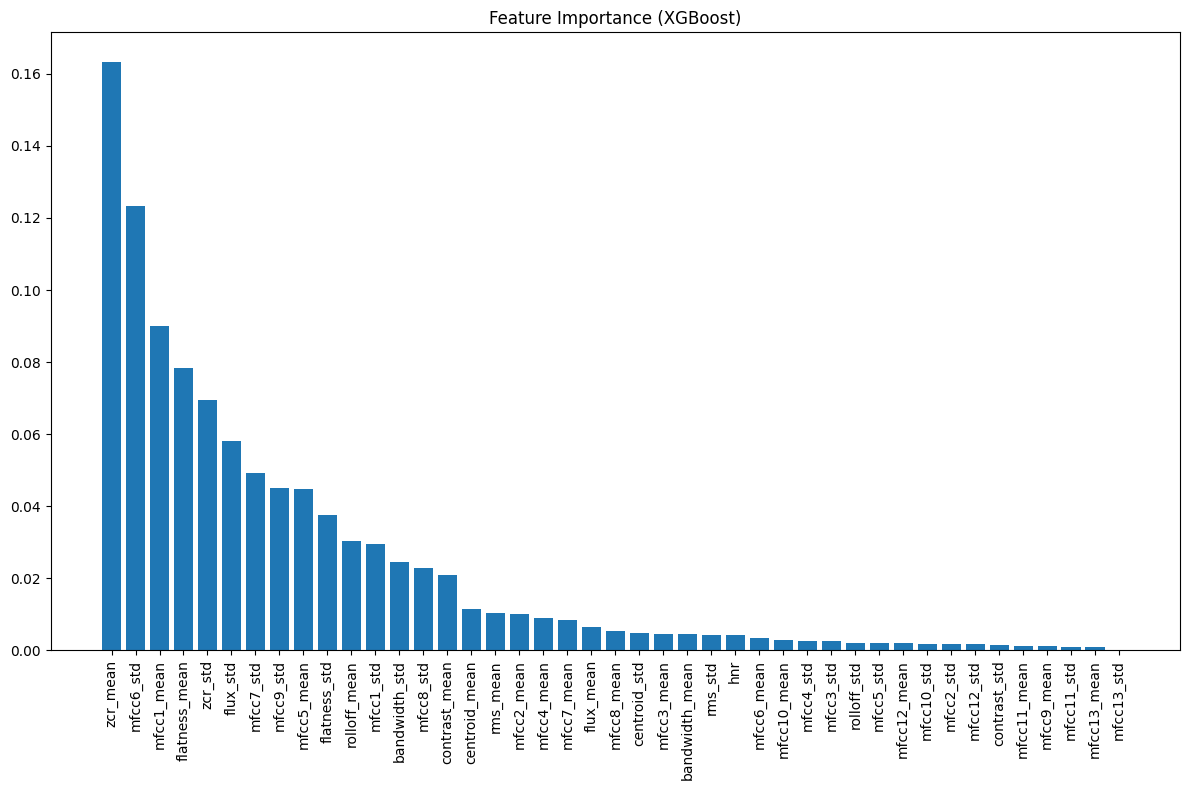


Top 15 vigtigste features:
zcr_mean: 0.1633
mfcc6_std: 0.1233
mfcc1_mean: 0.0902
flatness_mean: 0.0782
zcr_std: 0.0694
flux_std: 0.0582
mfcc7_std: 0.0493
mfcc9_std: 0.0451
mfcc5_mean: 0.0449
flatness_std: 0.0375
rolloff_mean: 0.0304
mfcc1_std: 0.0294
bandwidth_std: 0.0246
mfcc8_std: 0.0229
contrast_mean: 0.0209


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "/Users/lasseleekrogshave/Desktop/Uni/Semester 2/Gruppeprojekt P2/Training/P2Training.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant feature
if "filnavn" in df_train.columns:
    df_train = df_train.drop(columns=["filnavn"])


# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. XGBOOST MODEL
# ----------------------------
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "/Users/lasseleekrogshave/Desktop/Uni/Semester 2/Gruppeprojekt P2/Validering/P2Validering.csv"
df_test = pd.read_csv(test_path)

# Fjern kun irrelevant feature
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Split features og labels korrekt
X_test = df_test.drop(columns=["target"])
y_test_true = label_encoder.transform(df_test["target"])

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 7. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Print top 15 vigtigste features
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")